### RaschPy global MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Global(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:391: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_31938/186247924.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=42` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data.

In [4]:
sim = rp.MFRM_Sim_Global(no_of_items=12, no_of_persons=200, no_of_facet_elements=8, max_score=5, missing=0, seed=42)
sim.responses.to_csv('mfrm_global_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it (for a single file with a (Rater, Person) MultiIndex — see `loadup_mfrm_xlsx_tabs()`/`loadup_mfrm_multiple()` for one-sheet-per-rater or one-file-per-rater layouts). Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_global_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     5.0     5.0     4.0     1.0     4.0     2.0     2.0   
        Person_2     2.0     3.0     2.0     0.0     1.0     0.0     1.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     3.0     3.0      4.0      4.0      2.0  
        Person_2     1.0     2.0      0.0      0.0      0.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the global rater parameterisation (a single scalar severity per rater). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_global()

CPU times: user 5.45 ms, sys: 617 μs, total: 6.07 ms
Wall time: 5.85 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items.head(2)

Item_1   -1.161119
Item_2   -0.510907
dtype: float64

Since this is simulated data, we know the true generating item locations (`mfrm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')


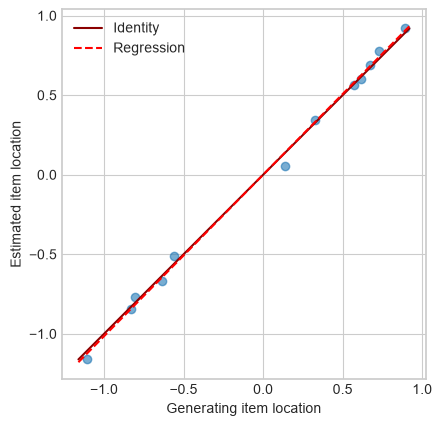

item location Pearson correlation:              0.999
item location SD ratio (estimated / generating): 1.017
item location regression coefficient:            1.015
item location RMSE:                              0.04


In [12]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item location', 'my_mfrm_global_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [13]:
%%time
mfrm.item_stats_df_global(full=True)
mfrm.item_stats_global.to_csv('mfrm_global_item_stats.csv')

CPU times: user 25.1 s, sys: 299 ms, total: 25.4 s
Wall time: 25.5 s


Check the item statistics table

In [14]:
mfrm.item_stats_global

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,-1.161,0.045,-1.244,-1.070,1600,0.691,0.956,-1.249,0.960,-1.132,0.697,0.682
Item_2,-0.511,0.038,-0.591,-0.438,1600,0.601,0.964,-1.019,1.000,0.003,0.704,0.712
Item_3,-0.772,0.041,-0.849,-0.693,1600,0.640,0.987,-0.347,0.988,-0.335,0.708,0.701
Item_4,0.563,0.040,0.488,0.643,1600,0.413,1.029,0.834,1.065,1.799,0.723,0.733
Item_5,-0.845,0.044,-0.933,-0.756,1600,0.646,1.027,0.776,0.992,-0.227,0.693,0.698
Item_6,0.054,0.037,-0.014,0.128,1600,0.493,1.044,1.229,1.048,1.335,0.739,0.729
Item_7,0.604,0.041,0.525,0.684,1600,0.410,1.008,0.250,0.977,-0.655,0.747,0.733
Item_8,0.346,0.040,0.265,0.418,1600,0.453,1.017,0.477,0.991,-0.236,0.735,0.733
Item_9,-0.669,0.040,-0.747,-0.590,1600,0.619,1.008,0.225,1.003,0.097,0.701,0.706
Item_10,0.919,0.048,0.827,1.008,1600,0.352,1.029,0.810,1.008,0.231,0.729,0.730


Generate a table of threshold statistics (and check run time), and save to file

In [15]:
%%time
mfrm.threshold_stats_df_global(full=True)
mfrm.threshold_stats_global.to_csv('mfrm_global_threshold_stats.csv')

CPU times: user 103 ms, sys: 2.77 ms, total: 105 ms
Wall time: 106 ms


Check the threshold statistics table

In [16]:
mfrm.threshold_stats_global

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-1.303,0.052,-1.396,-1.183,1.008,0.716,1.017,1.087,0.972,0.384,0.404
Threshold 2,-0.975,0.038,-1.043,-0.897,0.995,-0.441,1.000,0.013,1.012,0.390,0.380
Threshold 3,-0.785,0.031,-0.840,-0.720,1.001,0.130,0.998,-0.093,0.999,0.467,0.466
Threshold 4,1.163,0.037,1.080,1.231,1.004,0.417,1.002,0.120,0.991,0.557,0.566
Threshold 5,1.900,0.047,1.802,1.980,0.995,-0.407,1.015,0.802,1.004,0.584,0.580


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

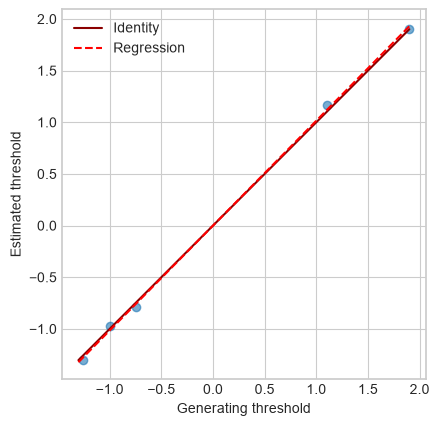

threshold Pearson correlation:              1.0
threshold SD ratio (estimated / generating): 1.016
threshold regression coefficient:            1.015
threshold RMSE:                              0.037


In [17]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_global_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [18]:
%%time
mfrm.rater_stats_df_global()
mfrm.rater_stats_global.to_csv('mfrm_global_rater_stats.csv')

CPU times: user 45.2 ms, sys: 1.7 ms, total: 46.9 ms
Wall time: 47 ms


Check the rater statistics table

In [19]:
mfrm.rater_stats_global

,Estimate,SE,Count,Infit MS,Outfit MS
Rater_1,-0.113,0.032,2400,1.005,0.987
Rater_2,0.071,0.029,2400,0.988,1.013
Rater_3,0.822,0.038,2400,1.010,1.004
Rater_4,-0.425,0.032,2400,0.994,0.981
Rater_5,0.727,0.036,2400,0.992,1.008
Rater_6,-1.183,0.039,2400,0.983,0.987
Rater_7,-0.028,0.032,2400,1.046,1.040
Rater_8,0.130,0.034,2400,1.041,1.030


And the same recovery check for rater severities, against `mfrm.generating.facet_effects`:

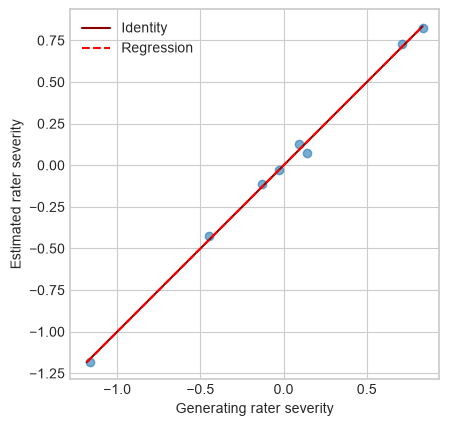

rater severity Pearson correlation:              0.999
rater severity SD ratio (estimated / generating): 1.002
rater severity regression coefficient:            1.0
rater severity RMSE:                              0.031


In [20]:
recovery_plot(mfrm.generating.facet_effects, mfrm.raters_global, 'rater severity', 'my_mfrm_global_rater_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [21]:
%%time
mfrm.person_stats_df_global(full=True)
mfrm.person_stats_global.to_csv('mfrm_global_person_stats.csv')

CPU times: user 14.7 ms, sys: 1.52 ms, total: 16.3 ms
Wall time: 16.3 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [22]:
mfrm.person_stats_global.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,0.424,0.108,0.111,289,480,0.602,1.046,1.048,0.365,0.378
Person_2,-1.673,0.116,0.117,101,480,0.210,1.017,0.855,0.160,-0.743
Person_3,1.351,0.124,0.130,359,480,0.748,1.106,1.065,0.719,0.472
Person_4,1.775,0.132,0.135,385,480,0.802,1.033,0.935,0.267,-0.366
Person_5,-3.200,0.196,0.178,25,480,0.052,0.826,0.985,-0.634,0.078
Person_6,-2.114,0.129,0.140,71,480,0.148,1.190,1.088,1.126,0.455
Person_7,0.286,0.107,0.103,277,480,0.577,0.937,0.921,-0.412,-0.528
Person_8,-0.404,0.103,0.108,213,480,0.444,1.105,1.088,0.792,0.653
Person_9,0.108,0.105,0.108,261,480,0.544,1.058,1.072,0.453,0.547
Person_10,-1.419,0.111,0.113,121,480,0.252,1.042,0.938,0.331,-0.309


And the same recovery check for person locations, against `mfrm.generating.persons`:

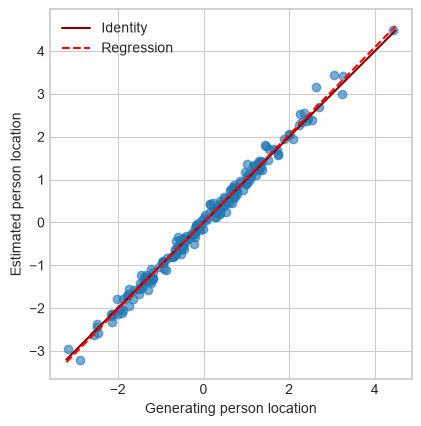

person location Pearson correlation:              0.995
person location SD ratio (estimated / generating): 1.026
person location regression coefficient:            1.021
person location RMSE:                              0.133


In [23]:
recovery_plot(mfrm.generating.persons, mfrm.persons_global, 'person location', 'my_mfrm_global_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [24]:
%%time
mfrm.test_stats_df_global()
mfrm.test_stats_global.to_csv('mfrm_global_test_stats.csv')

CPU times: user 3.04 ms, sys: 614 μs, total: 3.65 ms
Wall time: 3.59 ms


Check the test statistics table

In [25]:
mfrm.test_stats_global

,Items,Persons
Mean,0.000,0.005
SD,0.745,1.357
Separation ratio,18.038,11.262
Strata,24.384,15.349
Reliability,0.997,0.992


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [26]:
%%time
mfrm.item_res_corr_analysis_global()
mfrm.item_residual_correlations_global.to_csv('mfrm_global_item_residual_correlations.csv')
mfrm.item_loadings_global.to_csv('mfrm_global_item_loadings.csv')

CPU times: user 7.91 ms, sys: 2.65 ms, total: 10.6 ms
Wall time: 15.2 ms


View the table of pairwise item standard residual correlations

In [27]:
round(mfrm.item_residual_correlations_global, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,-0.026,-0.013,-0.026,0.004,0.027,-0.012,0.002,0.011,-0.019,0.021,0.025
Item_2,-0.026,1.000,-0.016,-0.009,0.001,0.025,0.002,-0.022,0.009,0.032,0.027,-0.041
Item_3,-0.013,-0.016,1.000,-0.013,0.016,-0.006,0.007,0.015,-0.021,-0.060,-0.037,0.027
Item_4,-0.026,-0.009,-0.013,1.000,-0.000,-0.031,-0.006,-0.039,0.026,0.020,0.006,-0.036
Item_5,0.004,0.001,0.016,-0.000,1.000,-0.032,-0.033,0.031,-0.033,-0.021,-0.032,-0.016
Item_6,0.027,0.025,-0.006,-0.031,-0.032,1.000,-0.017,-0.036,-0.059,-0.015,0.025,-0.019
Item_7,-0.012,0.002,0.007,-0.006,-0.033,-0.017,1.000,0.027,0.016,-0.005,-0.022,0.004
Item_8,0.002,-0.022,0.015,-0.039,0.031,-0.036,0.027,1.000,0.023,-0.045,0.058,-0.012
Item_9,0.011,0.009,-0.021,0.026,-0.033,-0.059,0.016,0.023,1.000,-0.018,0.002,0.008
Item_10,-0.019,0.032,-0.060,0.020,-0.021,-0.015,-0.005,-0.045,-0.018,1.000,-0.030,-0.021


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [28]:
round(mfrm.item_loadings_global['PC 1'], 3)

Item_1    -0.050
Item_2     0.138
Item_3    -0.137
Item_4     0.097
Item_5    -0.059
Item_6     0.066
Item_7    -0.028
Item_8    -0.124
Item_9    -0.012
Item_10    0.173
Item_11    0.033
Item_12   -0.116
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [29]:
%%time
mfrm.rater_res_corr_analysis_global()
mfrm.rater_residual_correlations_global.to_csv('mfrm_global_rater_residual_correlations.csv')
mfrm.rater_loadings_global.to_csv('mfrm_global_rater_loadings.csv')

CPU times: user 13.1 ms, sys: 777 μs, total: 13.9 ms
Wall time: 14 ms


View the table of pairwise rater standard residual correlations

In [30]:
round(mfrm.rater_residual_correlations_global, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,0.009,-0.016,-0.010,-0.020,-0.025,0.016,-0.026
Rater_2,0.009,1.000,0.023,-0.041,-0.031,-0.016,0.010,-0.013
Rater_3,-0.016,0.023,1.000,-0.049,-0.001,0.001,0.000,-0.015
Rater_4,-0.010,-0.041,-0.049,1.000,-0.010,-0.022,-0.006,-0.034
Rater_5,-0.020,-0.031,-0.001,-0.010,1.000,0.002,0.021,-0.017
Rater_6,-0.025,-0.016,0.001,-0.022,0.002,1.000,-0.054,0.012
Rater_7,0.016,0.010,0.000,-0.006,0.021,-0.054,1.000,0.011
Rater_8,-0.026,-0.013,-0.015,-0.034,-0.017,0.012,0.011,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [31]:
round(mfrm.rater_loadings_global['PC 1'], 3)

Rater_1    0.118
Rater_2   -0.188
Rater_3   -0.182
Rater_4    0.274
Rater_5    0.027
Rater_6   -0.072
Rater_7    0.034
Rater_8   -0.055
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

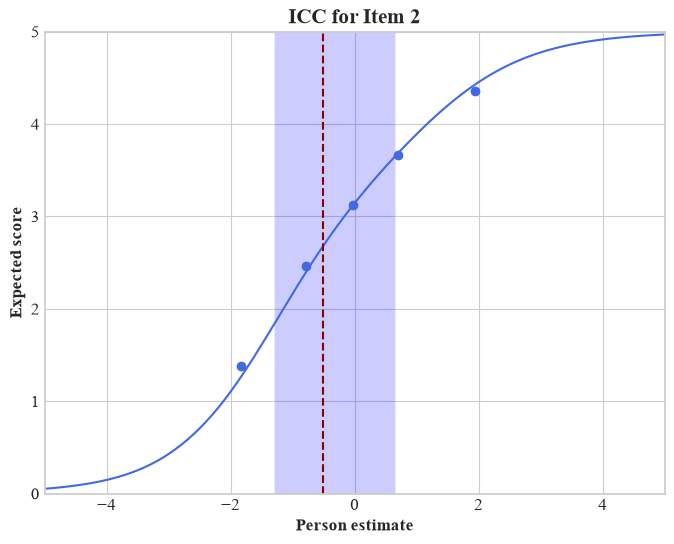

In [32]:
mfrm.icc_global('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3,
                xmin=-5, xmax=5, filename='my_mfrm_global_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

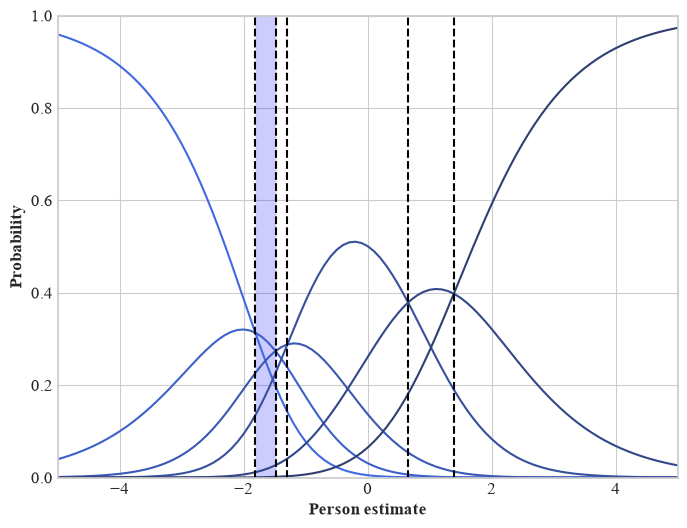

In [33]:
mfrm.crcs_global('Item_2', thresh_lines=True, cat_highlight=1, xmin=-5, xmax=5, filename='my_mfrm_global_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

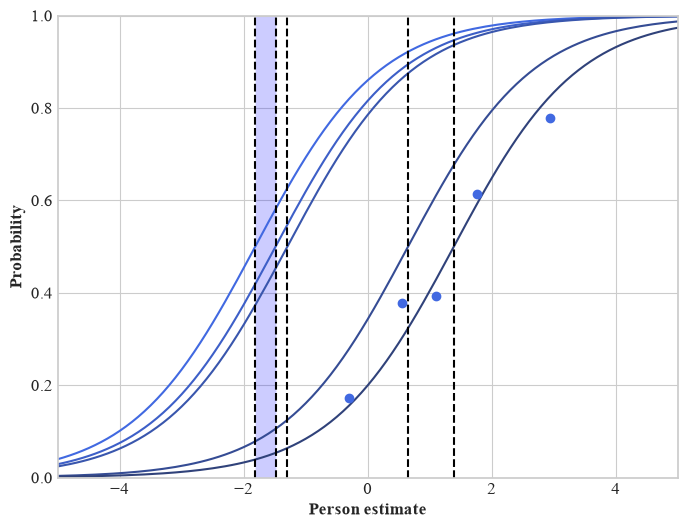

In [34]:
mfrm.threshold_ccs_global('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-5, xmax=5, filename='my_mfrm_global_threshold_ccs')

Produce an item information function curve for Item 2

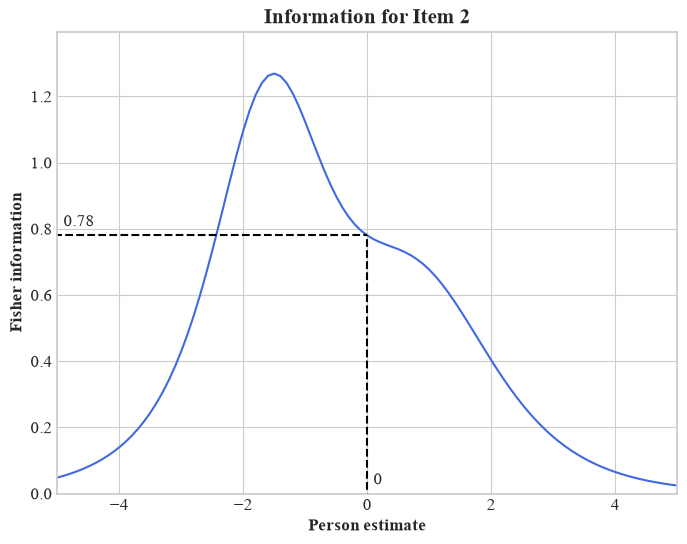

In [35]:
mfrm.iic_global('Item_2', point_info_lines=[0], point_info_labels=True, title='Information for Item 2',
                xmin=-5, xmax=5, filename='my_mfrm_global_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

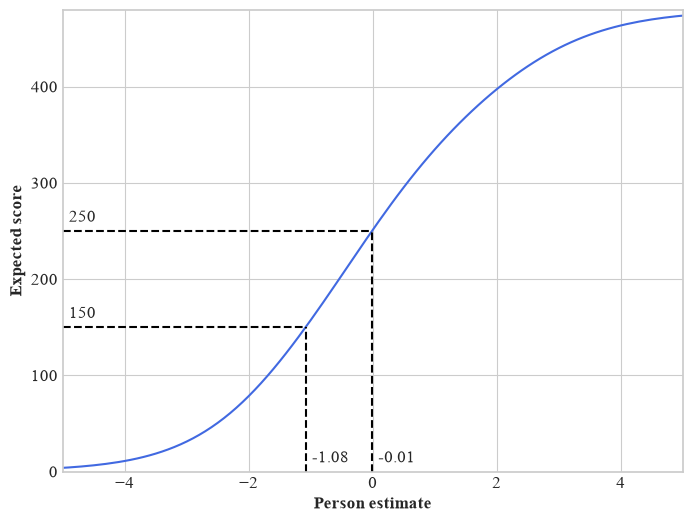

In [36]:
mfrm.tcc_global(score_lines=[150, 250], score_labels=True, filename='my_mfrm_global_tcc')

Produce a test information curve

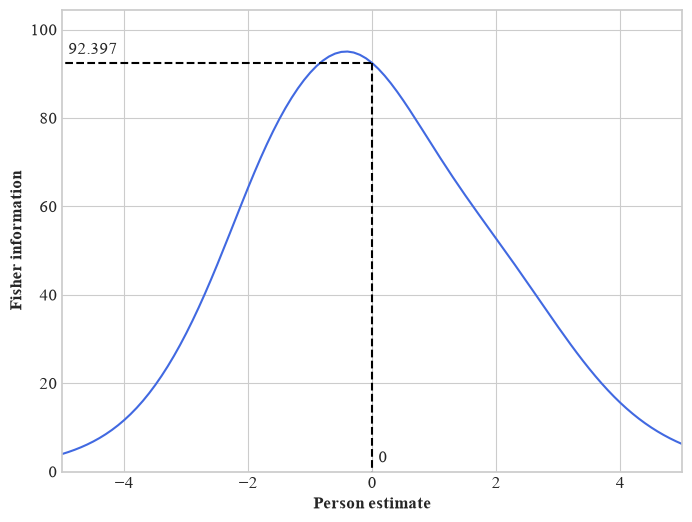

In [37]:
mfrm.test_info_global(point_info_lines=[0], point_info_labels=True, filename='my_mfrm_global_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

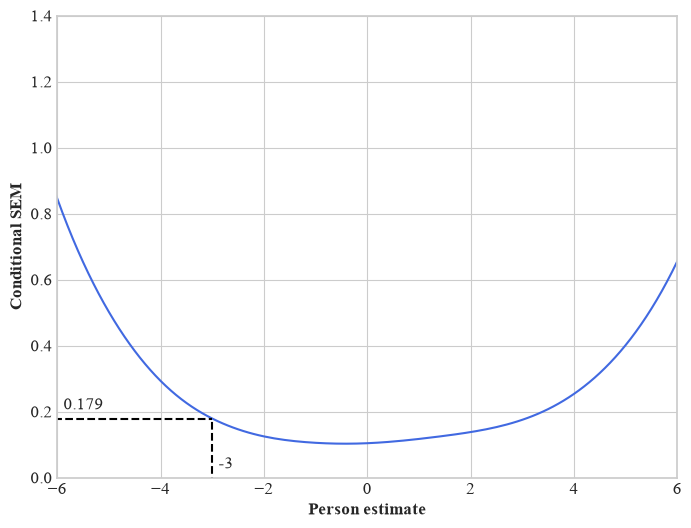

In [38]:
mfrm.test_csem_global(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-6, xmax=6, filename='my_mfrm_global_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

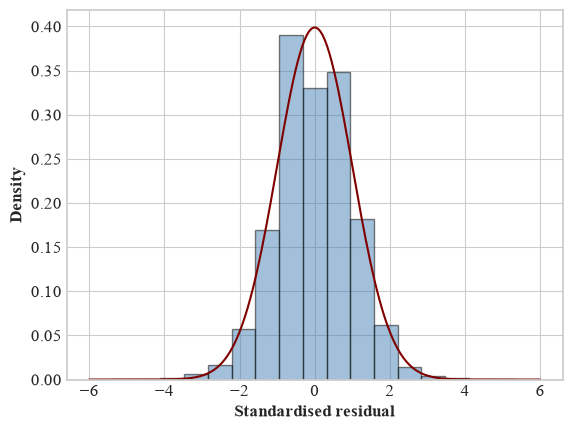

In [39]:
mfrm.std_residuals_plot_global(bin_width=0.6, normal=True, filename='my_mfrm_global_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [40]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_global_anchor(anchors)

CPU times: user 1.02 ms, sys: 461 μs, total: 1.48 ms
Wall time: 1.31 ms


Check the anchored rater severities against the unanchored ones.

In [41]:
rater_check = pd.DataFrame({'Unanchored': mfrm.raters_global,
                            'Anchored': mfrm.anchor_raters_global})
round(rater_check, 3)

,Unanchored,Anchored
Rater_1,-0.113,-0.202
Rater_2,0.071,-0.018
Rater_3,0.822,0.733
Rater_4,-0.425,-0.514
Rater_5,0.727,0.638
Rater_6,-1.183,-1.272
Rater_7,-0.028,-0.116
Rater_8,0.130,0.041
